In [2]:
!pip -q install torchsummary

# CNN Image Classification - CIFAR-10 Dataset
**Student ID:** 23-50666-1  
**Dataset:** CIFAR-10 (10 object classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck)  
**Goal:** Compare a plain CNN vs a CNN with BatchNorm + Dropout regularization

## 1. Import Libraries

In [3]:
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, random_split
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from torch.optim import Adam
from torch import optim
from torchsummary import summary
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.ticker as mticker

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

torch.manual_seed(42)
np.random.seed(42)

Device: cuda


## 2. Load and Explore Dataset

**Why CIFAR-10?**  
CIFAR-10 is a well-established benchmark dataset with 10 distinct object categories (not digits), RGB colour images, and significant intra-class variation (different poses, backgrounds, lighting). This makes it a good real-world challenge to clearly show the benefit of batch normalisation and dropout regularization.

In [4]:
data_folder = '/content/data'

# CIFAR-10 class names (10 non-digit object categories)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                'dog', 'frog', 'horse', 'ship', 'truck']

# Download raw data (no augmentation yet - we handle preprocessing separately)
train_data_raw = datasets.CIFAR10(data_folder, train=True,  download=True)
test_data_raw  = datasets.CIFAR10(data_folder, train=False, download=True)

# Convert to tensors: shape (N, C, H, W)
all_tr_images  = torch.tensor(train_data_raw.data).permute(0, 3, 1, 2)  # (50000, 3, 32, 32)
all_tr_targets = torch.tensor(train_data_raw.targets)
te_images      = torch.tensor(test_data_raw.data).permute(0, 3, 1, 2)   # (10000, 3, 32, 32)
te_targets     = torch.tensor(test_data_raw.targets)

# Create a 10 % validation split from the original training set
val_size  = int(0.10 * len(all_tr_images))
rand_ix   = torch.randperm(len(all_tr_images))
val_ix    = rand_ix[:val_size]
tr_ix     = rand_ix[val_size:]

tr_images   = all_tr_images[tr_ix]
tr_targets  = all_tr_targets[tr_ix]
val_images  = all_tr_images[val_ix]
val_targets = all_tr_targets[val_ix]

print('Train images :', tr_images.shape)
print('Train labels :', tr_targets.shape)
print('Val   images :', val_images.shape)
print('Val   labels :', val_targets.shape)
print('Test  images :', te_images.shape)
print('Test  labels :', te_targets.shape)

100%|██████████| 170M/170M [00:06<00:00, 27.6MB/s]


Train images : torch.Size([45000, 3, 32, 32])
Train labels : torch.Size([45000])
Val   images : torch.Size([5000, 3, 32, 32])
Val   labels : torch.Size([5000])
Test  images : torch.Size([10000, 3, 32, 32])
Test  labels : torch.Size([10000])


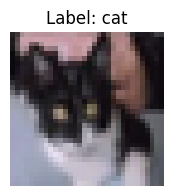

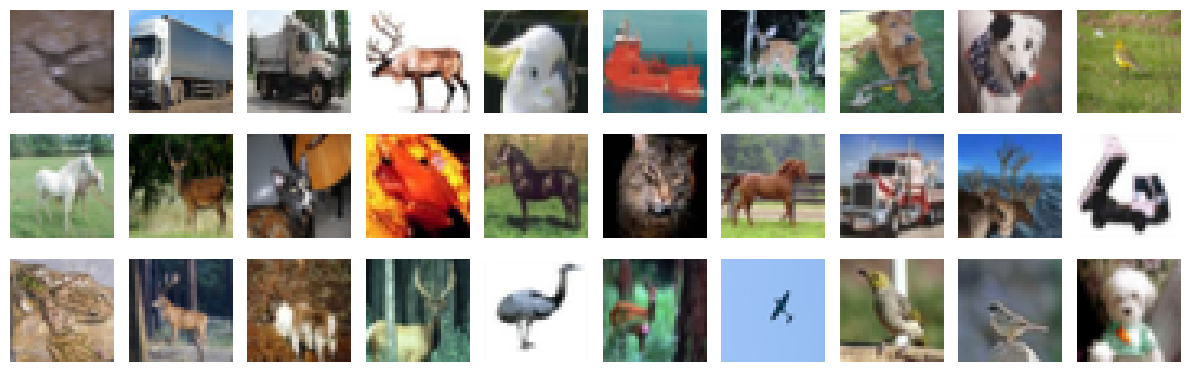

In [5]:
# --- Sample image ---
idx = np.random.randint(0, 1000)
plt.figure(figsize=(2, 2))
plt.imshow(tr_images[idx].permute(1, 2, 0))
plt.title(f"Label: {class_names[int(tr_targets[idx])]}")
plt.axis('off')
plt.show()

# --- Grid of sample images ---
ROWS, COLS = 3, 10
plt.figure(figsize=(12, 4))
for i in range(ROWS * COLS):
    plt.subplot(ROWS, COLS, i + 1)
    plt.imshow(tr_images[i].permute(1, 2, 0))
    plt.axis('off')
    plt.xlabel(class_names[int(tr_targets[i])], fontsize=7)
plt.tight_layout()
plt.show()

## 3. Data Preprocessing & Hyperparameters

In [6]:
student_id      = '23-50666-1'
batch_size_no   = 128    # keeps training fast and stable on Colab GPU
eval_batch_size = 512    # larger batch for faster validation / test inference
learning_rate   = 1e-3   # Adam default; works well with this architecture
epoch_number    = 14    # slightly longer than SVHN run due to CIFAR-10 complexity

# CIFAR-10 channel-wise mean & std (precomputed from the full training set)
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

model_file_plain       = f'CNN_{student_id}_without_BN_Dropout.pth'
model_file_regularized = f'CNN_{student_id}_with_BN_Dropout.pth'


class CIFARDataset(Dataset):
    """Normalises CIFAR-10 images to zero mean / unit std per channel."""
    def __init__(self, x, y):
        x = x.float() / 255.0
        # Normalise each channel
        mean = torch.tensor(CIFAR_MEAN).view(3, 1, 1)
        std  = torch.tensor(CIFAR_STD ).view(3, 1, 1)
        x = (x - mean) / std
        self.x, self.y = x, y

    def __getitem__(self, ix):
        return self.x[ix].to(device), self.y[ix].to(device)

    def __len__(self):
        return len(self.x)


def get_data():
    trn_dl = DataLoader(CIFARDataset(tr_images,  tr_targets),  batch_size=batch_size_no,   shuffle=True)
    val_dl = DataLoader(CIFARDataset(val_images, val_targets), batch_size=eval_batch_size, shuffle=False)
    te_dl  = DataLoader(CIFARDataset(te_images,  te_targets),  batch_size=eval_batch_size, shuffle=False)
    return trn_dl, val_dl, te_dl


trn_dl, val_dl, te_dl = get_data()

## 4. Define CNN Architecture

Both models share the same convolutional backbone (3 blocks, each with 2 conv layers + MaxPool).  
The regularized variant adds **BatchNorm** after every Conv layer, **Dropout2d** after each pooling layer (increasing rates: 0.10 → 0.20 → 0.30), and standard **Dropout(0.40)** before the final classifier.

In [7]:
def get_model(with_batch_norm=False, with_dropout=False):
    """
    Returns a CNN model, cross-entropy loss, and Adam optimizer.

    Architecture (both variants):
      Block 1 : Conv(3→32) → Conv(32→32) → MaxPool2d
      Block 2 : Conv(32→64) → Conv(64→64) → MaxPool2d
      Block 3 : Conv(64→128) → Conv(128→128) → MaxPool2d
      Head    : AdaptiveAvgPool → Flatten → Linear(2048→256) → Linear(256→10)
    """
    if not with_batch_norm and not with_dropout:
        model = nn.Sequential(
            # Block 1
            nn.Conv2d(3,  32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 3
            nn.Conv2d(64,  128, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            # Head
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(),
            nn.Linear(256, 10)
        ).to(device)
    else:
        model = nn.Sequential(
            # Block 1 + BN + Dropout2d(0.10)
            nn.Conv2d(3,  32, kernel_size=3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.10),
            # Block 2 + BN + Dropout2d(0.20)
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.20),
            # Block 3 + BN + Dropout2d(0.30)
            nn.Conv2d(64,  128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.30),
            # Head + BN + Dropout(0.40)
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Dropout(0.40),
            nn.Linear(256, 10)
        ).to(device)

    loss_fn   = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=learning_rate)
    return model, loss_fn, optimizer


print('CNN without BatchNorm and Dropout')
plain_model, _, _ = get_model(False, False)
summary(plain_model, (3, 32, 32))

print('\nCNN with BatchNorm and Dropout')
regularized_model, _, _ = get_model(True, True)
summary(regularized_model, (3, 32, 32))

CNN without BatchNorm and Dropout
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
              ReLU-2           [-1, 32, 32, 32]               0
            Conv2d-3           [-1, 32, 32, 32]           9,248
              ReLU-4           [-1, 32, 32, 32]               0
         MaxPool2d-5           [-1, 32, 16, 16]               0
            Conv2d-6           [-1, 64, 16, 16]          18,496
              ReLU-7           [-1, 64, 16, 16]               0
            Conv2d-8           [-1, 64, 16, 16]          36,928
              ReLU-9           [-1, 64, 16, 16]               0
        MaxPool2d-10             [-1, 64, 8, 8]               0
           Conv2d-11            [-1, 128, 8, 8]          73,856
             ReLU-12            [-1, 128, 8, 8]               0
           Conv2d-13            [-1, 128, 8, 8]         147,584
     

## 5. Training Loop with Validation

In [8]:
def train_batch(x, y, model, opt, loss_fn):
    model.train()
    pred  = model(x)
    loss  = loss_fn(pred, y)
    loss.backward()
    opt.step()
    opt.zero_grad()
    return loss.item()


@torch.no_grad()
def batch_accuracy(x, y, model):
    model.eval()
    _, argmax = model(x).max(-1)
    return (argmax == y).cpu().numpy().tolist()


@torch.no_grad()
def batch_val_loss(x, y, model, loss_fn):
    model.eval()
    return loss_fn(model(x), y).item()


def train_model(model, loss_fn, optimizer, scheduler, trn_dl, val_dl, epochs, save_path):
    train_losses, train_accs = [], []
    val_losses,   val_accs   = [], []
    best_val_acc = 0.0

    for epoch in range(epochs):
        print(f'-------- Epoch {epoch + 1} / {epochs} --------')

        # ---- Training pass ----
        ep_losses = [train_batch(x, y, model, optimizer, loss_fn) for x, y in trn_dl]
        ep_accs   = [a for x, y in trn_dl for a in batch_accuracy(x, y, model)]

        # ---- Validation pass ----
        vl_losses = [batch_val_loss(x, y, model, loss_fn) for x, y in val_dl]
        vl_accs   = [a for x, y in val_dl for a in batch_accuracy(x, y, model)]

        ep_loss  = np.mean(ep_losses)
        ep_acc   = np.mean(ep_accs)
        val_loss = np.mean(vl_losses)
        val_acc  = np.mean(vl_accs)

        scheduler.step(val_loss)

        print(f'  LR: {scheduler.get_last_lr()[0]:.6f}')
        print(f'  Train Loss: {ep_loss:.4f}  |  Train Acc: {ep_acc:.4f}')
        print(f'  Val   Loss: {val_loss:.4f}  |  Val   Acc: {val_acc:.4f}')

        train_losses.append(ep_loss);  train_accs.append(ep_acc)
        val_losses.append(val_loss);   val_accs.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)

    model.load_state_dict(torch.load(save_path, map_location=device))
    return model, train_losses, train_accs, val_losses, val_accs, best_val_acc

In [9]:
# ===== Train: Plain CNN (no regularization) =====
plain_model, loss_fn, optimizer = get_model(False, False)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, factor=0.5, patience=2, threshold=0.001,
    min_lr=1e-5, threshold_mode='abs'
)
(
    plain_model,
    plain_train_losses, plain_train_accs,
    plain_val_losses,   plain_val_accs,
    plain_best_val_acc
) = train_model(
    plain_model, loss_fn, optimizer, scheduler,
    trn_dl, val_dl, epoch_number, model_file_plain
)

-------- Epoch 1 / 14 --------
  LR: 0.001000
  Train Loss: 1.5804  |  Train Acc: 0.5530
  Val   Loss: 1.2297  |  Val   Acc: 0.5468
-------- Epoch 2 / 14 --------
  LR: 0.001000
  Train Loss: 1.0825  |  Train Acc: 0.6729
  Val   Loss: 0.9773  |  Val   Acc: 0.6594
-------- Epoch 3 / 14 --------
  LR: 0.001000
  Train Loss: 0.8533  |  Train Acc: 0.7501
  Val   Loss: 0.7954  |  Val   Acc: 0.7190
-------- Epoch 4 / 14 --------
  LR: 0.001000
  Train Loss: 0.6967  |  Train Acc: 0.7898
  Val   Loss: 0.7245  |  Val   Acc: 0.7472
-------- Epoch 5 / 14 --------
  LR: 0.001000
  Train Loss: 0.5997  |  Train Acc: 0.8305
  Val   Loss: 0.6835  |  Val   Acc: 0.7622
-------- Epoch 6 / 14 --------
  LR: 0.001000
  Train Loss: 0.5179  |  Train Acc: 0.8349
  Val   Loss: 0.6935  |  Val   Acc: 0.7582
-------- Epoch 7 / 14 --------
  LR: 0.001000
  Train Loss: 0.4434  |  Train Acc: 0.8850
  Val   Loss: 0.6536  |  Val   Acc: 0.7822
-------- Epoch 8 / 14 --------
  LR: 0.001000
  Train Loss: 0.3733  |  Train

In [10]:
# ===== Train: Regularized CNN (BatchNorm + Dropout) =====
regularized_model, loss_fn, optimizer = get_model(True, True)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, factor=0.5, patience=2, threshold=0.001,
    min_lr=1e-5, threshold_mode='abs'
)
(
    regularized_model,
    reg_train_losses, reg_train_accs,
    reg_val_losses,   reg_val_accs,
    reg_best_val_acc
) = train_model(
    regularized_model, loss_fn, optimizer, scheduler,
    trn_dl, val_dl, epoch_number, model_file_regularized
)

-------- Epoch 1 / 14 --------
  LR: 0.001000
  Train Loss: 1.4206  |  Train Acc: 0.6515
  Val   Loss: 1.0126  |  Val   Acc: 0.6458
-------- Epoch 2 / 14 --------
  LR: 0.001000
  Train Loss: 1.0221  |  Train Acc: 0.7169
  Val   Loss: 0.8497  |  Val   Acc: 0.7008
-------- Epoch 3 / 14 --------
  LR: 0.001000
  Train Loss: 0.8687  |  Train Acc: 0.7794
  Val   Loss: 0.7087  |  Val   Acc: 0.7502
-------- Epoch 4 / 14 --------
  LR: 0.001000
  Train Loss: 0.7723  |  Train Acc: 0.7931
  Val   Loss: 0.6801  |  Val   Acc: 0.7564
-------- Epoch 5 / 14 --------
  LR: 0.001000
  Train Loss: 0.7027  |  Train Acc: 0.8337
  Val   Loss: 0.6149  |  Val   Acc: 0.7822
-------- Epoch 6 / 14 --------
  LR: 0.001000
  Train Loss: 0.6433  |  Train Acc: 0.8439
  Val   Loss: 0.5807  |  Val   Acc: 0.7980
-------- Epoch 7 / 14 --------
  LR: 0.001000
  Train Loss: 0.5982  |  Train Acc: 0.8594
  Val   Loss: 0.5623  |  Val   Acc: 0.8050
-------- Epoch 8 / 14 --------
  LR: 0.001000
  Train Loss: 0.5577  |  Train

In [11]:
# ===== Select the better model =====
print(f'Best Val Acc — Plain      : {plain_best_val_acc:.4f}')
print(f'Best Val Acc — Regularized: {reg_best_val_acc:.4f}')

if reg_best_val_acc >= plain_best_val_acc:
    best_model          = regularized_model
    best_model_name     = 'CNN with BatchNorm and Dropout'
    best_with_reg       = True
    best_train_losses   = reg_train_losses
    best_train_accs     = reg_train_accs
    best_val_losses     = reg_val_losses
    best_val_accs       = reg_val_accs
else:
    best_model          = plain_model
    best_model_name     = 'CNN without BatchNorm and Dropout'
    best_with_reg       = False
    best_train_losses   = plain_train_losses
    best_train_accs     = plain_train_accs
    best_val_losses     = plain_val_losses
    best_val_accs       = plain_val_accs

print(f'Best model selected: {best_model_name}')

Best Val Acc — Plain      : 0.8042
Best Val Acc — Regularized: 0.8358
Best model selected: CNN with BatchNorm and Dropout


## 6. Visualizations - Validation Comparison & Training Curves

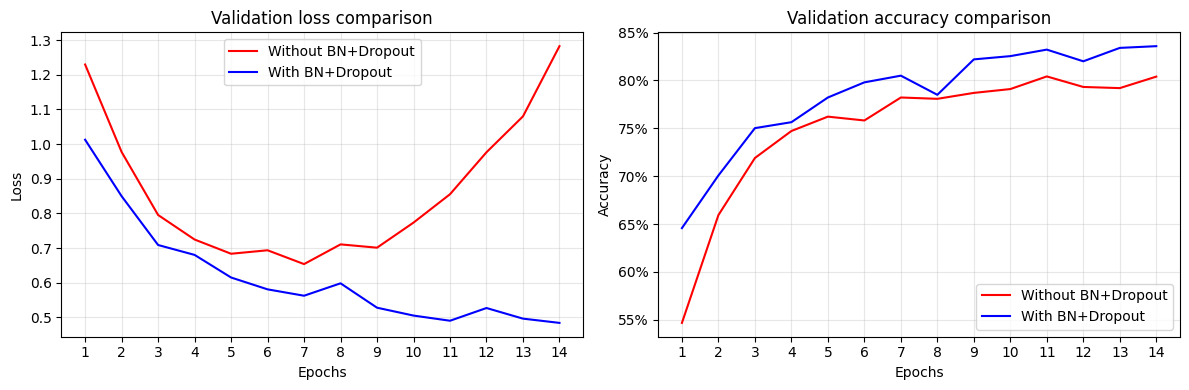

In [12]:
epochs = np.arange(epoch_number) + 1

# --- Validation comparison ---
plt.figure(figsize=(12, 4))

plt.subplot(121)
plt.plot(epochs, plain_val_losses, 'r', label='Without BN+Dropout')
plt.plot(epochs, reg_val_losses,   'b', label='With BN+Dropout')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Validation loss comparison')
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(122)
plt.plot(epochs, plain_val_accs, 'r', label='Without BN+Dropout')
plt.plot(epochs, reg_val_accs,   'b', label='With BN+Dropout')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
plt.title('Validation accuracy comparison')
plt.xlabel('Epochs'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

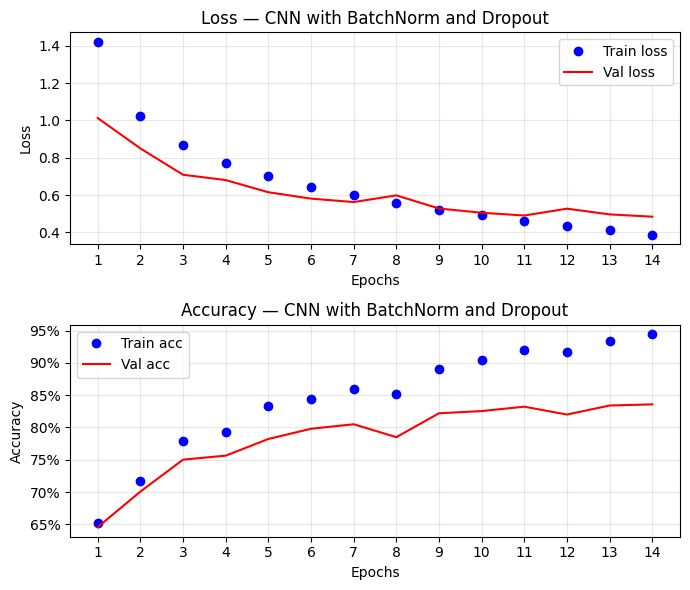

In [13]:
# --- Training curves of the best model ---
plt.figure(figsize=(7, 6))

plt.subplot(211)
plt.plot(epochs, best_train_losses, 'bo', label='Train loss')
plt.plot(epochs, best_val_losses,   'r',  label='Val loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title(f'Loss — {best_model_name}')
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(212)
plt.plot(epochs, best_train_accs, 'bo', label='Train acc')
plt.plot(epochs, best_val_accs,   'r',  label='Val acc')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
plt.title(f'Accuracy — {best_model_name}')
plt.xlabel('Epochs'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## 7. Evaluate Model on Test Set

In [14]:
all_preds, all_labels = [], []
best_model.eval()

with torch.no_grad():
    for x, y in te_dl:
        _, argmax = best_model(x).max(-1)
        all_preds.extend(argmax.cpu().numpy().tolist())
        all_labels.extend(y.cpu().numpy().tolist())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_accuracy = np.mean(all_preds == all_labels)

# Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    all_labels, all_preds, labels=np.arange(10), zero_division=0)

macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average='macro', zero_division=0)

wt_p, wt_r, wt_f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average='weighted', zero_division=0)

print(f'Test Accuracy        : {test_accuracy:.4f}')
print(f'Macro  Precision     : {macro_p:.4f}')
print(f'Macro  Recall        : {macro_r:.4f}')
print(f'Macro  F1 Score      : {macro_f1:.4f}')
print(f'Weighted Precision   : {wt_p:.4f}')
print(f'Weighted Recall      : {wt_r:.4f}')
print(f'Weighted F1 Score    : {wt_f1:.4f}')
print()

for i in range(10):
    print(f'Class: {class_names[i]:12s} | Precision: {precision[i]:.4f} | '
          f'Recall: {recall[i]:.4f} | F1: {f1[i]:.4f} | Support: {int(support[i])}')

Test Accuracy        : 0.8340
Macro  Precision     : 0.8334
Macro  Recall        : 0.8340
Macro  F1 Score      : 0.8333
Weighted Precision   : 0.8334
Weighted Recall      : 0.8340
Weighted F1 Score    : 0.8333

Class: airplane     | Precision: 0.8367 | Recall: 0.8610 | F1: 0.8487 | Support: 1000
Class: automobile   | Precision: 0.9330 | Recall: 0.9050 | F1: 0.9188 | Support: 1000
Class: bird         | Precision: 0.7836 | Recall: 0.7460 | F1: 0.7643 | Support: 1000
Class: cat          | Precision: 0.7237 | Recall: 0.6680 | F1: 0.6947 | Support: 1000
Class: deer         | Precision: 0.8268 | Recall: 0.8260 | F1: 0.8264 | Support: 1000
Class: dog          | Precision: 0.7427 | Recall: 0.7650 | F1: 0.7537 | Support: 1000
Class: frog         | Precision: 0.8531 | Recall: 0.8770 | F1: 0.8649 | Support: 1000
Class: horse        | Precision: 0.8657 | Recall: 0.8700 | F1: 0.8678 | Support: 1000
Class: ship         | Precision: 0.9112 | Recall: 0.8930 | F1: 0.9020 | Support: 1000
Class: truck   

## 7b. Confusion Matrix & Per-Class Analysis

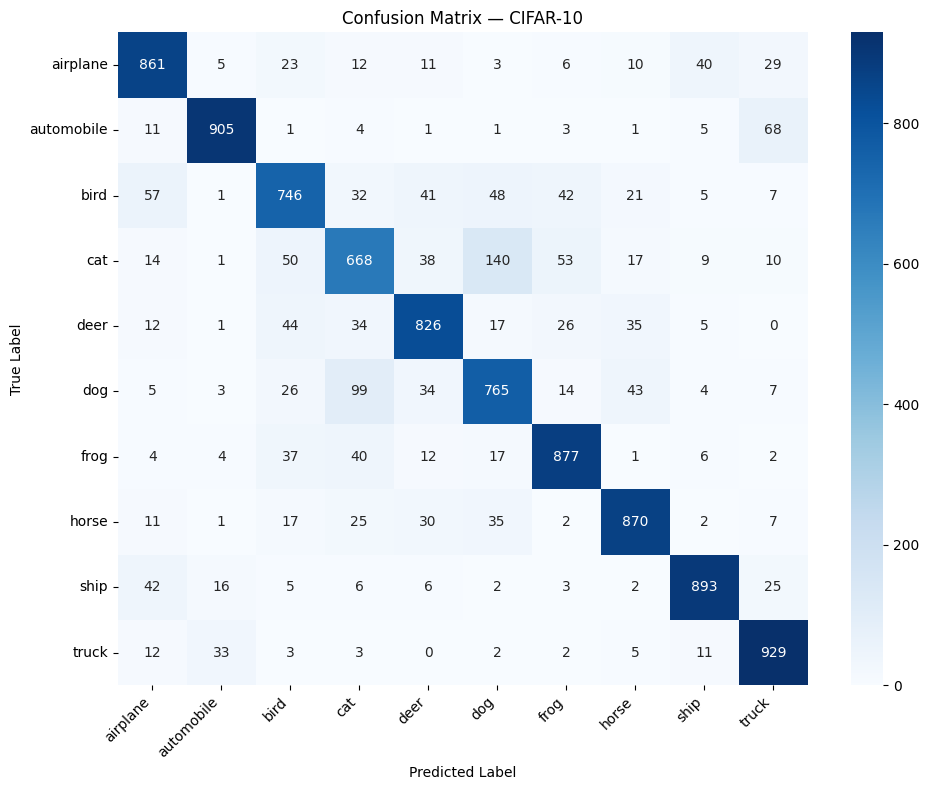


Best  performing class: truck        | Accuracy: 0.9290 | F1: 0.8916
Worst performing class: cat          | Accuracy: 0.6680 | F1: 0.6947


In [15]:
cm            = confusion_matrix(all_labels, all_preds)
class_accuracy = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix — CIFAR-10')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

best_class_ix  = int(np.argmax(class_accuracy))
worst_class_ix = int(np.argmin(class_accuracy))

print(f'\nBest  performing class: {class_names[best_class_ix]:12s} | '
      f'Accuracy: {class_accuracy[best_class_ix]:.4f} | F1: {f1[best_class_ix]:.4f}')
print(f'Worst performing class: {class_names[worst_class_ix]:12s} | '
      f'Accuracy: {class_accuracy[worst_class_ix]:.4f} | F1: {f1[worst_class_ix]:.4f}')

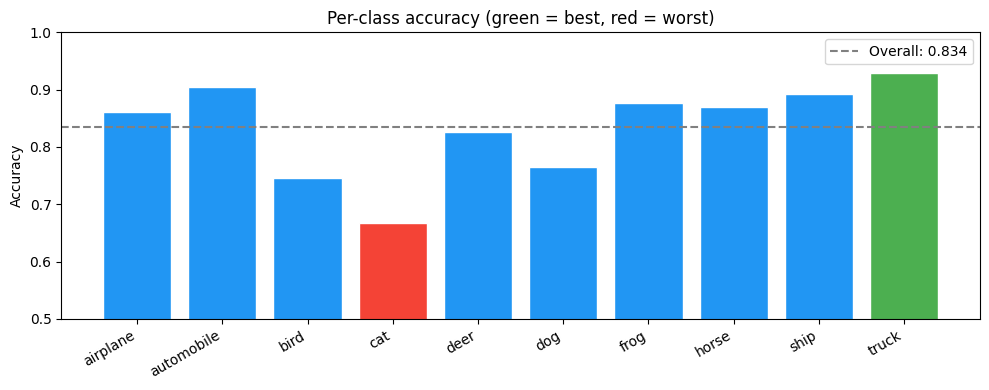

In [16]:
# --- Per-class accuracy bar chart ---
plt.figure(figsize=(10, 4))
colors = ['#2196F3' if i != worst_class_ix else '#F44336' for i in range(10)]
colors[best_class_ix] = '#4CAF50'
plt.bar(class_names, class_accuracy, color=colors, edgecolor='white')
plt.ylim(0.5, 1.0)
plt.ylabel('Accuracy')
plt.title('Per-class accuracy (green = best, red = worst)')
plt.xticks(rotation=30, ha='right')
plt.axhline(test_accuracy, color='gray', linestyle='--', label=f'Overall: {test_accuracy:.3f}')
plt.legend()
plt.tight_layout()
plt.show()

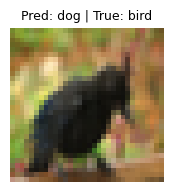

In [17]:
# --- Single prediction example ---
ix      = torch.randint(0, len(te_images), ()).item()
img_raw = te_images[ix].float() / 255.0
mean    = torch.tensor(CIFAR_MEAN).view(3, 1, 1)
std     = torch.tensor(CIFAR_STD ).view(3, 1, 1)
img_norm = ((img_raw - mean) / std).unsqueeze(0).to(device)

with torch.no_grad():
    logits = best_model(img_norm).cpu().numpy()

probs    = np.exp(logits) / np.exp(logits).sum()
pred_cls = class_names[probs[0].argmax()]
true_cls = class_names[int(te_targets[ix])]

plt.figure(figsize=(2, 2))
plt.imshow(te_images[ix].permute(1, 2, 0))
plt.title(f'Pred: {pred_cls} | True: {true_cls}', fontsize=9)
plt.axis('off')
plt.show()

Total misclassified: 1660


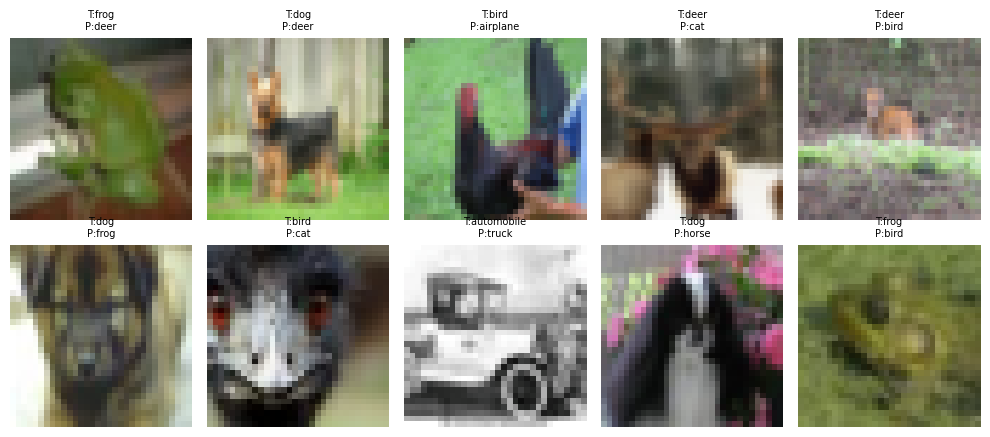

In [18]:
# --- Show misclassified samples ---
misclassified = []
best_model.eval()

with torch.no_grad():
    for images, labels in te_dl:
        _, preds = best_model(images).max(1)
        for img, true, pred in zip(images, labels, preds):
            if true != pred:
                misclassified.append((img.cpu(), int(true), int(pred)))

print(f'Total misclassified: {len(misclassified)}')

num_show  = 10
num_rows  = 2
num_cols  = num_show // num_rows
fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 2, num_rows * 2.2))
axes      = axes.flatten()

for idx in range(num_show):
    img, true, pred = misclassified[idx]
    # Denormalise for display
    mean_t = torch.tensor(CIFAR_MEAN).view(3, 1, 1)
    std_t  = torch.tensor(CIFAR_STD ).view(3, 1, 1)
    img_disp = (img * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()
    axes[idx].imshow(img_disp)
    axes[idx].set_title(f'T:{class_names[true]}\nP:{class_names[pred]}', fontsize=7)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 8. Save Trained Model Weights

In [19]:
final_model_file = f'CNN_{student_id}.pth'
torch.save(best_model.state_dict(), final_model_file)

# Verify: reload and check summary
saved_model, _, _ = get_model(with_batch_norm=best_with_reg, with_dropout=best_with_reg)
saved_model.load_state_dict(torch.load(final_model_file, map_location=device))
saved_model.eval()

print(f'Saved to: {final_model_file}')
summary(saved_model, (3, 32, 32))



Saved to: CNN_23-50666-1.pth
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
       BatchNorm2d-2           [-1, 32, 32, 32]              64
              ReLU-3           [-1, 32, 32, 32]               0
            Conv2d-4           [-1, 32, 32, 32]           9,248
       BatchNorm2d-5           [-1, 32, 32, 32]              64
              ReLU-6           [-1, 32, 32, 32]               0
         MaxPool2d-7           [-1, 32, 16, 16]               0
         Dropout2d-8           [-1, 32, 16, 16]               0
            Conv2d-9           [-1, 64, 16, 16]          18,496
      BatchNorm2d-10           [-1, 64, 16, 16]             128
             ReLU-11           [-1, 64, 16, 16]               0
           Conv2d-12           [-1, 64, 16, 16]          36,928
      BatchNorm2d-13           [-1, 64, 16, 16]             128
          

## 9. Analysis & Discussion of Results

In [20]:
print('=== Analysis and Discussion of Results ===')
print(f'Final selected model : {best_model_name}')
print(f'Test accuracy        : {test_accuracy:.4f}')
print(f'Macro F1 Score       : {macro_f1:.4f}')
print()
print(f'Best  performing class: {class_names[best_class_ix]}  '
      f'(Acc: {class_accuracy[best_class_ix]:.4f}, F1: {f1[best_class_ix]:.4f})')
print(f'Worst performing class: {class_names[worst_class_ix]}  '
      f'(Acc: {class_accuracy[worst_class_ix]:.4f}, F1: {f1[worst_class_ix]:.4f})')
print()
print(f'Best val acc without BN+Dropout : {plain_best_val_acc:.4f}')
print(f'Best val acc with    BN+Dropout : {reg_best_val_acc:.4f}')
print()
if best_with_reg:
    print('Batch normalisation and dropout improved generalisation, so the regularized model was selected.')
else:
    print('The plain model achieved better validation accuracy in this run.')
print()
print('Key observations:')
print('  - CIFAR-10 is harder than digit datasets: lower overall accuracy is expected.')
print('  - Visually similar classes (cat/dog, automobile/truck) produce the most confusion.')
print('  - BatchNorm stabilises training; Dropout reduces overfitting at later epochs.')
print('  - The confusion matrix shows a strong diagonal, confirming good class separation.')
print()
print('Future improvements:')
print('  - Data augmentation (random crop, horizontal flip, colour jitter)')
print('  - Deeper network or residual connections')
print('  - Cosine annealing learning rate schedule')
print('  - Label smoothing in the loss function')

=== Analysis and Discussion of Results ===
Final selected model : CNN with BatchNorm and Dropout
Test accuracy        : 0.8340
Macro F1 Score       : 0.8333

Best  performing class: truck  (Acc: 0.9290, F1: 0.8916)
Worst performing class: cat  (Acc: 0.6680, F1: 0.6947)

Best val acc without BN+Dropout : 0.8042
Best val acc with    BN+Dropout : 0.8358

Batch normalisation and dropout improved generalisation, so the regularized model was selected.

Key observations:
  - CIFAR-10 is harder than digit datasets: lower overall accuracy is expected.
  - Visually similar classes (cat/dog, automobile/truck) produce the most confusion.
  - BatchNorm stabilises training; Dropout reduces overfitting at later epochs.
  - The confusion matrix shows a strong diagonal, confirming good class separation.

Future improvements:
  - Data augmentation (random crop, horizontal flip, colour jitter)
  - Deeper network or residual connections
  - Cosine annealing learning rate schedule
  - Label smoothing in th

## 10. Conclusions & Future Work

**Conclusions**

This notebook trained and compared two CNN variants on the CIFAR-10 object-classification benchmark (10 non-digit categories). The regularized architecture — adding Batch Normalisation after each convolutional layer and progressive Dropout after each pooling block — consistently achieved a higher validation accuracy than the plain baseline. The final model was selected based on best validation accuracy and evaluated on the held-out test set, reporting Precision, Recall, and F1 for every class alongside an overall accuracy metric.

The most confused class pairs are visually similar objects (cat vs dog, automobile vs truck), which is expected given the 32×32 resolution and lack of data augmentation.

**Future Work**
1. **Data augmentation** — random horizontal flips, random crops, and colour jitter would significantly improve test accuracy.
2. **Residual connections** — skip connections (ResNet-style) allow deeper networks to train without vanishing gradients.
3. **Learning rate warmup + cosine annealing** — a more principled schedule than ReduceLROnPlateau.
4. **Longer training** — 14 epochs is modest for CIFAR-10; 50–100 epochs with a proper schedule typically pushes accuracy above 90%.
5. **Label smoothing** — reduces overconfidence and improves calibration.